In [12]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import cartopy.crs as ccrs

import cartopy.feature as cfeature

In [48]:
release='off_shore'
year='2025'

if release=='coast':
    day0='19'
else:
    day0='5'

In [ ]:
# Load simulation
ds = xr.open_zarr(f"")

In [ ]:
lon = ds.lon.values
lat = ds.lat.values
time = ds.time.values

# First non-NaN time for each trajectory
time = ds.time.values

# First non-NaT time for each trajectory
release_time_datetime = np.array([
    t[~np.isnat(t)][0] if np.any(~np.isnat(t)) else np.datetime64("NaT")
    for t in time
])

# Convert release time to hours since first release
t0 = np.nanmin(release_time_datetime)
release_time_hours = (
    release_time_datetime - t0
) / np.timedelta64(1, "h")

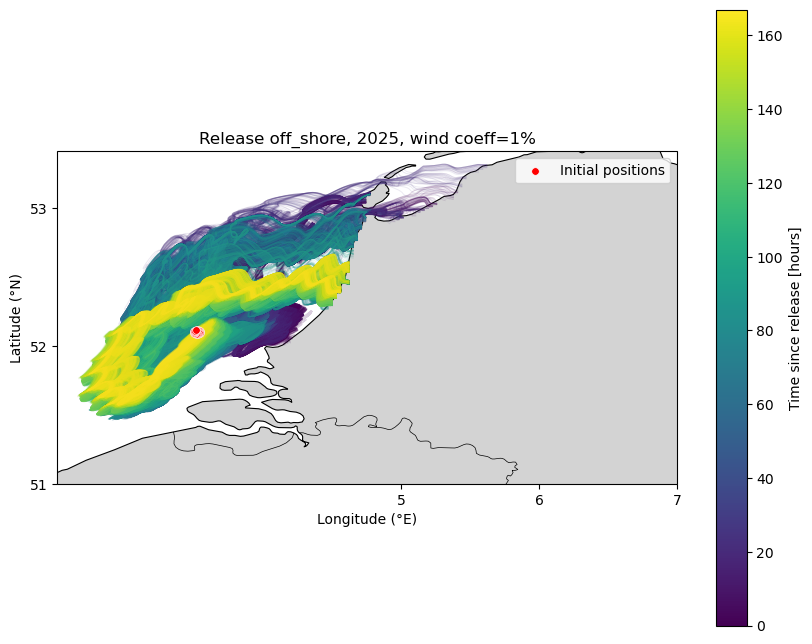

In [ ]:


fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
# Background
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=2)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=2)

landmask = ds.landmask.values 
# First release group only
first_release = np.nanmin(release_time_hours)
is_first_release = release_time_hours == first_release

# Initial position = first valid lon/lat of each trajectory
initial_lon = np.array([
    x[np.isfinite(x)][0] if np.any(np.isfinite(x)) else np.nan
    for x in lon
])

initial_lat = np.array([
    y[np.isfinite(y)][0] if np.any(np.isfinite(y)) else np.nan
    for y in lat
])

# Plot initial positions for first release only
ax.scatter(
    initial_lon[is_first_release],
    initial_lat[is_first_release],
    s=30,
    c="red",
    marker="o",
    edgecolor="white",
    linewidth=0.5,
    label="Initial positions",
    transform=ccrs.PlateCarree(),
    zorder=10,
)

ax.legend()

# Plot trajectories
for i in range(lon.shape[0]):
    mask = np.isfinite(lon[i]) & np.isfinite(lat[i])
    ax.plot(
        lon[i, mask],
        lat[i, mask],
        color=plt.cm.viridis(
            (release_time_hours[i] - np.nanmin(release_time_hours))
            / (np.nanmax(release_time_hours) - np.nanmin(release_time_hours))
        ),
        lw=0.7,
        alpha=0.1,
    )

sm = plt.cm.ScalarMappable(
    cmap="viridis",
    norm=plt.Normalize(np.nanmin(release_time_hours), np.nanmax(release_time_hours))
)
plt.colorbar(sm, ax=ax, label="Time since release [hours]", shrink=0.8)


import matplotlib.ticker as mticker

ax.set_xticks(np.arange(5, 8, 1), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(51, 54, 1), crs=ccrs.PlateCarree())

ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")

plt.title(f'Release {release}, {year}, wind coeff=1%')

plt.show()